In [1]:
print("hello")

hello


In [2]:
import torch

In [3]:
import numpy as np
np.random.seed(0)


In [ ]:
points_per_class = 100
classes = 3

X=np.zeros((points_per_class*classes, 2) )
y=np.zeros(points_per_class*classes, dtype=int)
X.shape
y.shape

(300,)

In [46]:
for class_num in range(classes):
    ix=range(
        points_per_class*class_num, 
        points_per_class*(class_num+1)
    )
    r=np.linspace(0.0, 1, points_per_class)

    theta=np.linspace(
        class_num*4, 
        (class_num+1)*4,
        points_per_class
        )
    theta+=np.random.randn(points_per_class)*0.2

    X[ix] = np.c_[r * np.sin(theta), r * np.cos(theta)]
    y[ix] = class_num




In [32]:
np.linspace(0.0,1.0,num=5, endpoint=False)

array([0. , 0.2, 0.4, 0.6, 0.8])

In [47]:
y.shape

(300,)

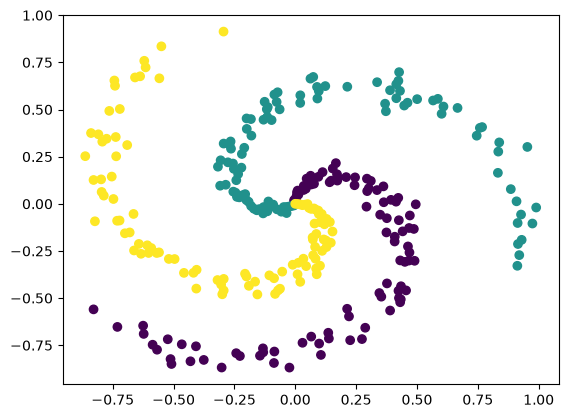

In [49]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1],c=y)
plt.show()

In [51]:
#Network
input_size=2
hidden_size=20
output_size=3

In [56]:
w1=np.random.randn(input_size, hidden_size)
b1=np.zeros((1, hidden_size))

w2=np.random.randn(hidden_size, output_size)
b2=np.zeros((1, output_size))

learning_rate=1.0
print(w1.shape)
print(w2.shape)
print(b1.shape)
print(b2.shape)

(2, 20)
(20, 3)
(1, 20)
(1, 3)


In [61]:
#fordward propagation

for epoch in range(100000):
    z1=X@w1+b1

    a1 = np.maximum(0, z1)

    #layer2
    logits=a1@w2+b2

    #softmax
    exp_scores = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    correct_probs = probs[np.arange(len(X)), y]

    loss = -np.mean(np.log(correct_probs + 1e-9))

    #back prop
    # softmax + cross entropy derivative
    dlogits = probs.copy()
    dlogits[np.arange(len(X)), y] -= 1
    dlogits /= len(X)

    # Layer 2 gradients
    dW2 = a1.T @ dlogits
    db2 = np.sum(dlogits, axis=0, keepdims=True)

    # Gradient flowing backwards into hidden layer
    da1 = dlogits @ w2.T

    # ReLU derivative
    dz1 = da1.copy()
    dz1[z1 <= 0] = 0

    # Layer 1 gradients
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    #update
    w1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    w2 -= learning_rate * dW2
    b2 -= learning_rate * db2


    if epoch % 1000 == 0:
        predictions = np.argmax(probs, axis=1)
        accuracy = np.mean(predictions == y)

        print(
            f"Epoch {epoch:5d} | "
            f"Loss: {loss:.4f} | "
            f"Accuracy: {accuracy:.3f}"
        )




Epoch     0 | Loss: 0.0185 | Accuracy: 0.993
Epoch  1000 | Loss: 0.0180 | Accuracy: 0.993
Epoch  2000 | Loss: 0.0176 | Accuracy: 0.993
Epoch  3000 | Loss: 0.0172 | Accuracy: 0.993
Epoch  4000 | Loss: 0.0168 | Accuracy: 0.993
Epoch  5000 | Loss: 0.0165 | Accuracy: 0.993
Epoch  6000 | Loss: 0.0162 | Accuracy: 0.993
Epoch  7000 | Loss: 0.0160 | Accuracy: 0.993
Epoch  8000 | Loss: 0.0157 | Accuracy: 0.993
Epoch  9000 | Loss: 0.0155 | Accuracy: 0.993
Epoch 10000 | Loss: 0.0153 | Accuracy: 0.993
Epoch 11000 | Loss: 0.0152 | Accuracy: 0.993
Epoch 12000 | Loss: 0.0150 | Accuracy: 0.993
Epoch 13000 | Loss: 0.0148 | Accuracy: 0.993
Epoch 14000 | Loss: 0.0147 | Accuracy: 0.993
Epoch 15000 | Loss: 0.0146 | Accuracy: 0.993
Epoch 16000 | Loss: 0.0144 | Accuracy: 0.993
Epoch 17000 | Loss: 0.0143 | Accuracy: 0.993
Epoch 18000 | Loss: 0.0142 | Accuracy: 0.993
Epoch 19000 | Loss: 0.0141 | Accuracy: 0.993
Epoch 20000 | Loss: 0.0140 | Accuracy: 0.993
Epoch 21000 | Loss: 0.0139 | Accuracy: 0.993
Epoch 2200

In [63]:
np.set_printoptions(precision=4, suppress=True)

print("W1 =")
print(w1)

print("\nb1 =")
print(b1)

print("\nW2 =")
print(w2)

print("\nb2 =")
print(b2)

W1 =
[[ -9.95    -2.2415  -0.9232  -2.8571  -7.223    1.61     4.9571  -1.3639
    3.272   -5.5707  -4.1222 -10.077    6.3419  -4.9216 -14.7825   0.0132
    6.5063  -7.9829  -3.585    4.9079]
 [  5.5291   3.1346  -4.232   -6.2593 -12.2919   4.8149  -4.6687  11.9206
   -1.6398   7.747   11.1787  -3.539    1.7997   3.6545  -0.6727   0.117
    3.4735  -5.4734 -10.5184  -9.203 ]]

b1 =
[[-2.9541 -0.1034 -1.6967 -0.1996  1.0437  0.1131 -0.506   2.8138  5.2006
  -0.2811 -0.3138 -0.3189 -2.3139 -2.0336  0.409  -0.3277 -0.9858 -0.5535
  -0.1852 -0.2612]]

W2 =
[[  0.2159  -8.2846   8.3767]
 [ -3.1574   0.7402   2.2491]
 [  3.0122   0.1191  -3.8175]
 [  5.1896  -3.6759   1.4589]
 [ -8.1277  11.8465  -0.9598]
 [  3.0292  -4.017    0.4727]
 [  3.8535   2.2564  -5.5062]
 [  9.3921  -1.7683  -7.8014]
 [ -4.1501  -2.1113   4.6109]
 [ -8.5459   0.6021   4.5678]
 [ -9.0737   5.7071   4.6448]
 [ -1.2505  -7.619    7.298 ]
 [ -4.8602   5.1552   1.6457]
 [ -0.1193  -3.6826   5.0212]
 [  5.4117   7.1848 -